In [28]:
import subprocess
import sys
import os

local_lib = os.path.expanduser('~/my_local_packages')

# installing packages 
subprocess.check_call([sys.executable, "-m", "pip", "install", "--target", local_lib, "requests", 
                       #"duckduckgo_search", 
                       "opencv-python-headless",
                       "numpy<2.0", 
                       "scikit-learn"])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 137.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 138.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 152.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.9/216.9 kB 411.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 344.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 414.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.7/135.7 kB 267.7 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 159.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 MB 166.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


0

In [15]:
import shutil
import getpass
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
import numpy as np
import torch
import torchvision
from torchvision import transforms
import torchvision.models
import torch.nn as nn
import torch.nn.functional as F  # needed for supcon math because reliant on cosine similarity so F.normalize needed to project 
#plastic features onto hyperspace so model can group PET together and push other RIC#'s away'
import torch.optim as optim      # For the AdamW optimizer
from torchvision.models import swin_b, Swin_B_Weights # Specific Swin-B access
import gc
from torch.amp import autocast, GradScaler
from sklearn.manifold import TSNE
import cv2
import torch
from torch.utils.data import Dataset
from PIL import Image
import random

ModuleNotFoundError: No module named 'sklearn'

In [ ]:

#defining a function to extract images of wadaba dataset plastics with OpenCV and convert it to a mask
def extract_any_plastic(image_path):
    img = cv2.imread(image_path) #loading images
    if img is None: return None, None #safety check for broken file path
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    #goal: simplify data for shape detection
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)#changing to gray & black
    blurred = cv2.GaussianBlur(gray, (7, 7), 0) #adding noise
    #and adds noise
    #https://docs.opencv.org/3.4/da/d22/tutorial_py_canny.html
    edges = cv2.Canny(blurred, 10, 80)#Canny Edge Detector
    
    kernel = np.ones((15, 15), np.uint8) 
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel) #clasing the gaps in the image
    
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    mask_solid = np.zeros(gray.shape, dtype=np.uint8)
    if contours:
        largest_cnt = max(contours, key=cv2.contourArea)
        cv2.drawContours(mask_solid, [largest_cnt], -1, 255, -1)
    #returns color image and black and white mask    
    return img_rgb, mask_solid

#function to take random background image from DTD dataset, and splices the photos together to make a fake dataset
#bitwise masking 
def swap_to_dtd(plastic_img, plastic_mask, dtd_root):
    categories = [d for d in os.listdir(dtd_root) if os.path.isdir(os.path.join(dtd_root, d))]
    chosen_cat = random.choice(categories)
    cat_path = os.path.join(dtd_root, chosen_cat)
    
    bg_files = [f for f in os.listdir(cat_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    if not bg_files: return plastic_img
        
    bg_path = os.path.join(cat_path, random.choice(bg_files))
    bg_img = cv2.imread(bg_path)
    bg_img = cv2.resize(bg_img, (plastic_img.shape[1], plastic_img.shape[0]))
    

    bg_hole = cv2.bitwise_and(bg_img, bg_img, mask=cv2.bitwise_not(plastic_mask))
    plastic_only = cv2.bitwise_and(cv2.cvtColor(plastic_img, cv2.COLOR_RGB2BGR), 
                                   cv2.cvtColor(plastic_img, cv2.COLOR_RGB2BGR), 
                                   mask=plastic_mask)
    
    return cv2.add(bg_hole, plastic_only)

input_folder = "/projectnb/ec523/projects/finalProjectPlastic/0_Data/wadaba_local" #raw images
dtd_folder = "dtd_data/dtd/images"

#making subfolders 
output_base = 'wadaba_final_package'
images_out = os.path.join(output_base, 'images')
labels_out = os.path.join(output_base, 'masks')

for path in [images_out, labels_out]:
    os.makedirs(path, exist_ok=True)


print("Generating dataset and labels...")
for filename in os.listdir(input_folder):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        file_path = os.path.join(input_folder, filename)
        
        # 1. Extract
        original_rgb, mask = extract_any_plastic(file_path)
        
        if original_rgb is not None and np.any(mask):
            # generate textured image
            textured_bgr = swap_to_dtd(original_rgb, mask, dtd_folder)
            
            #save image
            cv2.imwrite(os.path.join(images_out, filename), textured_bgr)
            
            # save Mask (Label)
            cv2.imwrite(os.path.join(labels_out, filename), mask)
            
            print(f"Processed: {filename}")

print(f"\nFinished! to the '{output_base}' folder.")

Generating dataset and labels...
Processed: 0024_a01b00c2d3e0f1g0h2.jpg
Processed: 0029_a01b00c2d0e0f0g0h0.jpg
Processed: 0063_a02b01c2d1e0f1g1h0.jpg
Processed: 0094_a01b99c1d0e0f1g0h3.jpg
Processed: 0055_a01b00c1d0e0f1g1h1.jpg
Processed: 0025_a01b04c2d3e0f1g0h4.jpg
Processed: 0072_a06b01c2d3e0f0g0h0.jpg
Processed: 0017_a01b00c1d1e0f1g0h2.jpg
Processed: 0034_a06b01c2d0e0f0g0h4.jpg
Processed: 0075_a02b01c2d0e0f0g0h1.jpg
Processed: 0081_a01b04c1d2e0f1g0h0.jpg
Processed: 0068_a01b00c2d3e0f1g0h1.jpg
Processed: 0080_a05b00c1d2e0f1g0h2.jpg
Processed: 0023_a02b01c1d2e0f1g0h2.jpg
Processed: 0098_a02b03c2d2e0f0g0h1.jpg
Processed: 0047_a01b00c1d3e0f0g1h2.jpg
Processed: 0026_a01b00c1d2e1f1g0h4.jpg
Processed: 0049_a01b00c1d1e0f0g0h3.jpg
Processed: 0019_a06b01c2d3e0f0g0h1.jpg
Processed: 0073_a01b00c2d3e0f0g0h1.jpg
Processed: 0032_a05b01c1d0e0f0g0h4.jpg
Processed: 0049_a01b00c1d1e0f0g0h4.jpg
Processed: 0072_a06b01c1d0e0f0g0h0.jpg
Processed: 0031_a05b01c2d0e0f0g0h2.jpg
Processed: 0046_a01b00c2d3e1f1g

Premature end of JPEG file


Processed: 0005_a01b03c2d3e0f1g1h3.jpg
Processed: 0022_a05b00c2d1e0f0g0h4.jpg
Processed: 0060_a06b01c1d1e0f0g0h2.jpg
Processed: 0038_a05b01c1d3e0f0g0h3.jpg
Processed: 0082_a01b00c1d2e0f1g0h2.jpg
Processed: 0035_a06b01c2d1e0f0g0h0.jpg
Processed: 0061_a02b01c2d3e0f1g0h0.jpg
Processed: 0008_a01b00c2d2e0f1g0h2.jpg
Processed: 0060_a06b01c1d3e0f0g0h2.jpg
Processed: 0079_a01b00c2d3e0f1g0h0.jpg
Processed: 0018_a01b04c1d0e0f0g1h1.jpg
Processed: 0054_a05b05c1d1e0f0g0h1.jpg
Processed: 0042_a01b01c1d1e0f1g1h4.jpg
Processed: 0074_a01b00c1d0e0f1g0h0.jpg
Processed: 0056_a01b00c2d3e0f1g0h4.jpg
Processed: 0089_a01b00c2d2e0f1g0h1.jpg
Processed: 0048_a01b00c2d0e0f0g0h0.jpg
Processed: 0062_a02b05c1d2e0f1g1h3.jpg
Processed: 0037_a01b04c1d0e0f1g1h0.jpg
Processed: 0044_a06b01c1d2e0f0g0h1.jpg
Processed: 0010_a02b01c2d0e0f1g0h2.jpg
Processed: 0065_a02b03c1d1e0f1g0h3.jpg
Processed: 0072_a06b01c2d3e0f0g0h1.jpg
Processed: 0027_a01b04c2d1e0f0g0h4.jpg
Processed: 0027_a01b04c2d3e0f0g0h1.jpg
Processed: 0051_a01b00c1d

In [22]:
# using absolute path to data
local_path = "/projectnb/ec523/projects/finalProjectPlastic/0_Data/wadaba_local"

BATCH_SIZE = 8

Found image at: /projectnb/ec523/projects/finalProjectPlastic/0_Data/wadaba_local/0024_a01b00c2d3e0f1g0h2.jpg


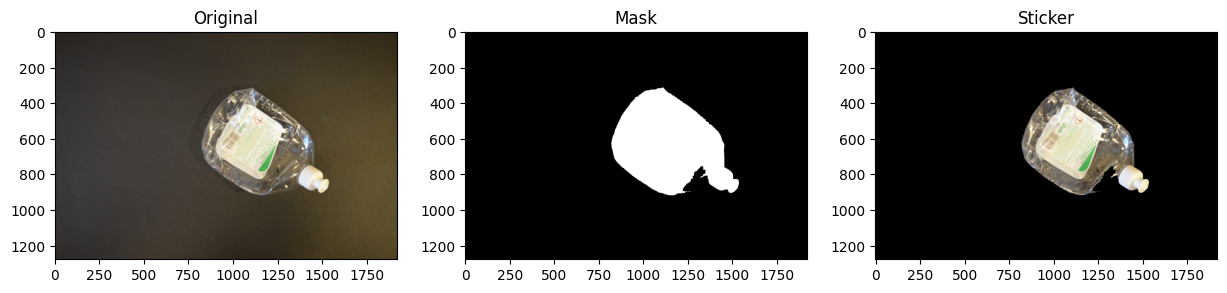

In [7]:
#sticket test
found_path = None
for root, dirs, files in os.walk(local_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            found_path = os.path.join(root, file)
            break
    if found_path: break

if found_path:
    print(f"Found image at: {found_path}")
    # extraction
    original, mask = extract_any_plastic(found_path)
    
    # Create the sticker
    sticker = cv2.bitwise_and(original, original, mask=mask)
    
    # show
    plt.figure(figsize=(15, 5))
    plt.subplot(1,3,1); plt.imshow(original); plt.title("Original")
    plt.subplot(1,3,2); plt.imshow(mask, cmap='gray'); plt.title("Mask")
    plt.subplot(1,3,3); plt.imshow(sticker); plt.title("Sticker")
    plt.show()
else:
    print(" No images found!")

In [20]:
!python --version

Python 3.10.12


In [3]:
#creating special class that is synthetic/"wild"
class WadabaWildDataset(Dataset):
    def __init__(self, root_dir, dtd_dir=None, transform=None, p_swap=0.5): #p_swap is probability of a background swap to
        #get 50% classic wadaba and 50% synthetic images
        self.root_dir = root_dir
        self.transform = transform
        self.p_swap = p_swap
        self.image_files = [f for f in os.listdir(root_dir) if f.lower().endswith(('.jpg', '.png'))]
        self.label_map = {'a00':0, 'a01':1, 'a02':2, 'a03':3, 'a04':4, 'a05':5, 'a06':6, 'a07':7}
        
        # Index DTD
        self.dtd_paths = []
        if dtd_dir:
            for root, dirs, files in os.walk(dtd_dir):
                for f in files:
                    if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                        self.dtd_paths.append(os.path.join(root, f))

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.root_dir, img_name)
        
        # Label Logic
        label = 0
        for code, idx_val in self.label_map.items():
            if code in img_name.lower():
                label = idx_val
                break

        if self.dtd_paths and random.random() < self.p_swap:
            try:
                original, mask = extract_any_plastic(img_path)
                mask = cv2.GaussianBlur(mask, (5, 5), 0) #disguising edges 
             
                swapped = swap_to_dtd(original, mask, self.dtd_paths)
                image = Image.fromarray(swapped) # Already RGB
            except:
                image = Image.open(img_path).convert("RGB")
        else:
            image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

In [ ]:
!nvidia-smi

In [11]:
#torch.cuda.is_available()

print(torch.version.cuda)

12.8


In [2]:
cudaDevice = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
#code is taken directly from github https://github.com/HobbitLong/SupContrast/blob/master/losses.py#L11
class SupConLoss(nn.Module):
    """Supervised Contrastive Learning: https://arxiv.org/pdf/2004.11362.pdf"""
    def __init__(self, temperature=0.07, contrast_mode='all',
                 base_temperature=0.07):
        super(SupConLoss, self).__init__()
        self.temperature = temperature
        self.contrast_mode = contrast_mode
        self.base_temperature = base_temperature
        
        """Compute loss for model. If both `labels` and `mask` are None,
        it degenerates to SimCLR unsupervised loss:
        https://arxiv.org/pdf/2002.05709.pdf

        Args:
            features: hidden vector of shape [bsz, n_views, ...].
            labels: ground truth of shape [bsz].
            mask: contrastive mask of shape [bsz, bsz], mask_{i,j}=1 if sample j
                has the same class as sample i. Can be asymmetric.
        Returns:
            A loss scalar.
        """

    def forward(self, features, labels=None, mask=None):
        device = (torch.device('cuda')
                  if features.is_cuda
                  else torch.device('cpu'))

        if len(features.shape) < 3:
            raise ValueError('`features` needs to be [bsz, n_views, ...],'
                             'at least 3 dimensions are required')
        if len(features.shape) > 3:
            features = features.view(features.shape[0], features.shape[1], -1)

        batch_size = features.shape[0]
        if labels is not None and mask is not None:
            raise ValueError('Cannot define both `labels` and `mask`')
        elif labels is None and mask is None:
            mask = torch.eye(batch_size, dtype=torch.float32).to(device)
        elif labels is not None:
            labels = labels.contiguous().view(-1, 1)
            if labels.shape[0] != batch_size:
                raise ValueError('Num of labels does not match num of features')
            mask = torch.eq(labels, labels.T).float().to(device) #code creates a matrix of your batch, compares to images and gets assigned a number
        else:
            mask = mask.float().to(device)

        contrast_count = features.shape[1]
        contrast_feature = torch.cat(torch.unbind(features, dim=1), dim=0)
        if self.contrast_mode == 'one':
            anchor_feature = features[:, 0]
            anchor_count = 1
        elif self.contrast_mode == 'all':
            anchor_feature = contrast_feature
            anchor_count = contrast_count
        else:
            raise ValueError('Unknown contrast mode: {}'.format(self.contrast_mode))

        # compute logits
        #math operation that calculates the Cosine Similarity between every single image in your batch
        #The Dot Product: Measures how much two vectors "overlap."
        #Temperature (tau): hyperparameter (you have it set to 0.07). It scales the distances. A low temperature makes the model "stricter"
        #—it punishes even small mistakes heavily, forcing the clusters to be extremely tight
        anchor_dot_contrast = torch.div(
            torch.matmul(anchor_feature, contrast_feature.T),
            self.temperature)
        
        # for numerical stability
        logits_max, _ = torch.max(anchor_dot_contrast, dim=1, keepdim=True)
        logits = anchor_dot_contrast - logits_max.detach()

        # tile mask
        mask = mask.repeat(anchor_count, contrast_count)
        # mask-out self-contrast cases
        #blanking out the center of the matrix so model is forced to learn from other images not just itself
        logits_mask = torch.scatter(
            torch.ones_like(mask),
            1,
            torch.arange(batch_size * anchor_count).view(-1, 1).to(device),
            0
        )
        mask = mask * logits_mask

        # compute log_prob
        #to make the loss small, the model must make the positive similarities very large 
        #and the negative similarities (different plastics) very small
        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True))

        # compute mean of log-likelihood over positive
        mean_log_prob_pos = (mask * log_prob).sum(1) / mask.sum(1)

        # loss
        loss = - (self.temperature / self.base_temperature) * mean_log_prob_pos
        loss = loss.view(anchor_count, batch_size).mean()

        return loss

In [18]:
class TwoViewTransform:
    def __init__(self, base_transform):
        self.base_transform = base_transform
    def __call__(self, x):
        return [self.base_transform(x), self.base_transform(x)]


supcon_train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(size=224, scale=(0.2, 1.0)), 
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([
        transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [19]:

data_path = "/projectnb/ec523/projects/finalProjectPlastic/0_Data/wadaba_local"

#Update the path to DTD images
dtd_path = "dtd_data/dtd/images"

trainingSet = [639,3402,441,464,3153,1889,3005,3145,3512,2396,2831,2957,703,76,2724,1284,2440,1469,1698,3258,850,3251,3922,1507,1310,728,785,393,3915,1927,3963,1000,592,3192,912,3572,2322,1959,545,2913,2830,2473,3435,1869,479,1331,2151,3761,3352,2923,482,2436,1285,3269,602,1629,267,2916,3677,3540,2734,1595,3062,3434,3391,3674,245,1920,811,489,2805,3573,2372,3021,2576,2635,1738,2333,600,3381,2034,2412,685,1009,228,1555,2299,2355,2713,768,2350,3863,1416,1861,449,2579,755,810,1767,3386,765,3079,1583,1512,1845,3084,2943,2925,1630,2019,238,54,295,2217,1997,3531,3740,3171,1955,621,1119,996,1727,2668,2868,3729,2835,2975,1219,2860,1936,911,926,1556,935,708,3669,1919,2417,2760,3585,2678,1005,3072,2196,3482,3172,3928,1424,2749,93,3230,578,1405,1138,746,70,3100,2076,2212,2526,3051,395,861,1766,335,217,3170,1776,2846,512,1562,1863,3013,1879,2279,3431,1077,1216,213,1028,2470,2876,1086,3983,2320,3617,1128,2475,3314,2105,1239,7,2658,3270,2006,340,668,903,2574,3456,908,236,3350,3567,2870,2203,241,3935,1996,136,2216,2822,3473,30,2136,3651,665,1066,188,1217,1740,3288,3698,3460,1493,2384,2798,2100,3769,622,1497,331,3092,252,1223,989,2492,528,1342,3713,3805,923,301,716,3971,2059,1398,781,2767,47,2088,2044,3283,3163,1948,1816,1520,1472,3004,3604,484,3131,673,1330,505,1785,2101,2792,723,2147,552,2247,1286,3977,3996,3796,2834,106,1038,2164,400,3696,1686,3727,3613,2675,3343,927,1298,3931,1795,1901,2143,2990,3210,771,428,775,1151,299,3162,2013,804,3117,1664,1272,2385,184,2341,1247,309,2937,2626,1311,2399,1754,1249,953,3095,152,2843,3126,1940,1394,2392,3144,2077,2338,916,2380,677,868,407,40,1723,2976,3666,1407,3124,992,1899,3592,1968,828,3115,1387,1052,3787,3447,3788,1265,1942,366,2319,1883,879,205,2446,3866,3764,3202,1015,3872,459,2795,2052,2266,79,1518,2329,1374,1736,2924,2131,2110,2823,753,326,3979,3070,635,291,3365,1995,2158,1800,3656,1705,1724,2912,3818,1728,6,3492,3947,930,1978,1231,1150,3562,1167,3,490,3542,847,444,1864,2306,1414,1684,2309,1718,1756,3304,247,1749,1476,691,1019,1292,1379,1657,314,2774,3479,937,42,1847,2942,2932,33,1409,2972,575,1317,1646,931,807,1308,1026,2413,2995,1819,1655,1582,2518,3786,2323,2933,3910,374,624,3007,1865,3588,533,3827,202,12,1141,2114,24,1558,1974,356,3059,3025,381,1032,577,2437,1093,3799,3837,2813,2340,406,3829,3349,1040,1762,2345,2029,3768,3307,2390,3639,2777,2698,1575,3268,1612,2740,2608,1305,836,1550,742,2558,520,266,2549,3808,878,1260,2585,1887,3804,3377,629,3312,3066,2317,2704,909,1696,3760,1419,3826,1105,3616,1111,1483,3864,1654,2119,2679,3882,3773,1637,1932,3029,2855,2572,517,620,3459,2894,2455,3793,3543,1123,1811,1638,547,1649,3240,1056,1585,1168,870,3621,2667,1303,347,3965,610,2227,3675,1642,3436,646,3086,420,318,1672,3519,1025,532,1508,3568,3896,1306,2425,1316,3211,2996,1805,421,3338,1114,1341,3274,3440,3806,1506,2408,2415,5,1529,2162,2866,1946,2874,375,566,3179,289,2284,2047,1513,2480,2684,2352,1708,2955,1852,943,264,783,1868,1521,3660,1203,3576,3581,3243,1014,1044,2858,358,779,191,3986,3470,85,1639,3705,447,3106,2985,687,2270,2627,3488,1422,1172,344,3507,683,2790,244,3112,2826,766,1069,3825,559,3322,3535,1062,1841,2234,1924,581,3984,1275,2252,1610,2671,2773,802,777,316,3398,2696,1498,1533,2477,2721,3694,1224,3096,379,803,3746,745,1189,3502,2428,1380,1522,1644,922,3640,2014,919,3328,940,522,1568,3516,3918,1747,1794,1802,3927,2939,1234,2997,1085,1479,2902,1244,271,3372,53,1163,1799,204,3462,1591,2434,1803,328,150,1586,2890,1893,499,3257,3700,2983,1434,3504,1515,1071,1786,3730,3597,2828,1701,28,3987,2872,1177,2612,3952,749,3668,698,2318,317,1384,3168,2045,3132,1338,899,2532,2714,3395,2573,2083,2195,159,540,1145,3347,370,2662,3393,1323,2837,1856,1411,2657,2581,1475,1087,86,2739,2695,345,1103,3335,3130,2419,1998,717,13,2000,408,2672,1471,1634,1131,2945,359,1618,95,2098,587,573,3861,3489,3109,3913,3474,1420,1973,2327,1307,1257,3881,1807,1725,2454,1083,197,2126,2107,2003,1721,696,510,219,310,738,2022,2647,1922,1124,588,1501,3380,3738,1294,1023,1752,31,2641,1053,721,1632,1653,980,1679,2242,714,1532,2879,133,37,2548,1299,2063,1282,571,2541,167,3344,655,1538,1064,2793,3263,1711,3387,3949,196,3030,2687,1430,170,123,3618,3612,2648,1592,3259,1152,672,675,1935,963,3156,477,3000,3122,3407,2600,58,2288,3451,413,661,1371,3342,258,0,2738,611,3510,3615,417,3478,3560,1241,561,2791,891,3102,180,2705,3158,2880,3298,3697,3834,526,498,2490,585,2463,2344,1372,2737,2021,2231,3190,3946,615,3204,388,2062,1761,3242,3385,580,2122,200,336,1089,2781,1748,2192,108,3362,3229,3695,1830,3556,1788,3565,3701,2515,3330,1207,3670,1884,1418,1505,492,538,1340,2556,1790,260,3775,3982,3879,3812,3281,1733,3421,3902,938,3034,3024,560,3284,3311,456,97,2418,2185,967,1185,496,1215,671,3956,269,3645,1541,1060,3091,939,3384,1855,3483,976,1793,2993,3846,1871,3101,3999,2589,3250,199,2636,3948,3570,654,1880,3643,2941,88,2313,1941,3280,1227,1771,1369,3241,1910,160,1500,14,3040,3185,2377,1180,3418,1673,113,263,1784,300,2982,2241,3797,2221,3374,320,3399,195,3071,3525,2620,2429,2452,1993,2958,1262,772,3303,1441,2583,950,3974,3262,1491,3184,1906,1448,1110,1943,2432,1435,129,3895,609,1070,1702,2179,1614,21,1157,3649,218,419,3657,1302,973,2001,3410,993,1002,2259,1456,1801,2459,3035,2611,1977,2661,1735,2451,1900,1181,2569,3265,2193,3119,2801,543,2305,2189,3925,410,3924,1781,3082,3287,72,3104,2245,3582,705,2652,2501,2666,59,3186,3814,1986,914,2884,2402,761,2130,2735,84,2008,3860,2159,2677,3267,2172,327,3653,1365,2586,905,1921,1626,3791,2533,730,3406,1403,541,282,80,763,3871,3810,71,699,1033,3247,3176,1839,132,667,1989,3981,2546,2009,2670,3772,1347,3528,3541,3049,1304,2959,2171,3001,3465,3703,476,2378,565,1671,1139,1154,2645,637,3970,2604,3292,3886,1288,182,1423,2743,2260,3196,1903,2951,3367,1624,1,493,606,2081,1375,3403,1982,1848,727,841,325,2199,2977,380,1197,1546,1473,1720,790,3404,1683,568,224,2934,1174,3901,2806,1029,3012,1658,243,3437,2517,824,298,2748,627,3619,883,1442,2918,1984,2984,458,3143,2808,220,2325,893,3422,1107,617,2042,881,1133,1905,2903,3690,2686,2141,3045,1827,2035,704,1622,3742,1043,1716,46,3752,2851,1815,1382,2400,431,3506,954,287,148,2909,1504,1873,2483,262,465,2157,614,1579,183,3533,1354,226,103,2543,955,2075,2373,3009,2115,1970,952,2820,3426,551,970,3865,1760,190,3595,3847,2690,2799,77,3332,968,2381,43,198,759,2397,1240,3583,357,369,3559,1652,3785,2360,3253,44,1588,1328,958,1259,3628,2886,2489,210,1175,1693,2161,3023,3877,3264,2239,1628,2409,1449,1450,2301,1485,480,2730,642,3884,808,3054,3438,3676,1963,640,2986,3252,3873,1367,3782,1439,1670,2794,3317,702,2435,660,3759,1834,454,1904,3911,1129,3816,2853,472,1489,1822,1279,3382,2481,1315,1818,1274,3822,888,2850,2733,1179,3157,2342,3754,3226,1917,3942,349,2255,2561,791,2940,1931,695,50,2180,2308,3998,830,3587,2631,1866,3239,2591,3140,3817,1334,2825,567,2888,898,3755,206,1806,81,143,371,1527,3887,435,1135,3073,383,2936,1205,3178,593,3839,760,2218,3193,2547,643,3840,2146,1779,2456,2493,1798,1137,2973,1722,2294,1042,3108,2423,3832,2854,265,1401,3301,641,2315,2507,546,1336,2121,634,2812,2829,1557,3003,1726,1046,3441,272,1844,942,1944,1118,1826,3709,1134,3058,1772,297,2601,153,3466,638,1386,1526,172,1264,1470,1225,1503,3890,2271,1368,2285,1352,2283,2683,2394,257,569,1160,1813,2596,2258,1058,2864,2689,229,3351,3136,3476,1041,27,3455,253,1003,941,3424,1467,2577,3652,2575,1810,3735,1953,3584,3685,1913,2085,2361,1601,3611,1198,2509,3527,1577,767,101,2207,20,2503,2885,2324,2804,2038,857,427,3138,2233,3750,3711,1433,713,2471,508,2981,2660,1487,1037,2699,653,2092,2111,890,2148,2176,2020,1576,1862,1320,48,3026,2229,2025,2028,2867,2905,3511,678,1734,3088,3577,1267,2343,65,3249,321,1243,500,3203,3094,1656,1689,3481,2166,2334,1886,3093,312,662,633,2637,1553,2335,3995,3593,2922,342,2513,1994,446,3369,2314,3880,3491,2994,2710,3392,1061,2646,957,2109,3606,1674,2535,910,3868,1022,3321,2430,3368,376,1277,2036,127,3815,3545,140,2238,2358,3496,1688,801,270,3486,2961,762,1593,3340,863,956,3586,1444,2883,3485,756,2935,3041,718,392,2552,1392,867,1295,2788,2802,49,1359,535,3934,2103,2523,3631,3941,3693,1059,2703,2303,2183,1291,3390,2316,426,3579,3897,3702,164,3850,3366,433,618,3234,805,3309,1846,3758,2920,437,2616,945,1950,1233,1335,1969,3899,3195,623,1445,837,3849,2152,2370,2746,648,1661,161,1991,2307,3152,3346,2992,1012,2433,3430,1031,647,467,3205,1050,240,2815,1870,3279,2970,3361,2261,1561,1132,115,360,2557,404,333,1361,2727,3020,2055,3780,3121,2665,886,674,2643,1220,3414,1918,3159,3774,1651,562,1024,3800,3468,2280,3637,2297,1495,594,1992,1068,2030,2504,75,986,3932,2080,530,3042,2989,2002,1236,2952,3990,3439,2244,865,363,871,73,3536,1833,2486,657,1837,3469,2551,1792,2458,2718,2113,1825,3063,1840,2614,390,550,3334,784,2633,259,2776,1509,39,2072,1200,754,2610,1477,1268,1633,3299,3546,1159,1186,2833,3875,362,3500,1242,1894,1742,1187,3686,3844,1144,3475,1933,1552,2723,3724,3664,1572,3415,3513,2353,2354,146,3197,815,3722,1804,1296,1389,900,907,583,3305,1519,3969,3636,2891,1613,398,2688,147,98,3089,2250,2818,1146,3566,3008,2609,1542,3277,2154,2086,2478,2598,227,2379,255,1202,1399,1645,3261,1212,3161,3518,2836,1451,821,3167,1313,429,1755,3166,2862,2118,1091,3326,1324,8,2240,3823,1554,2702,2491,4,3852,3174,177,3708,124,2527,1158,2832,818,656,368,3997,1712,2930,729,311,866,194,556,887,1965,1669,2194,3591,1744,2761,2722,3654,3068,2024,736,1530,1094,663,948,1232,2910,62,2215,3458,1102,2584,2445,1263,290,3771,2251,3497,3689,145,2018,1344,3602,3206,2906,1570,3120,934,2560,1017,764,2810,1912,1773,3721,1289,2139,3155,329,1525,2439,1821,558,2362,1907,3517,1764,3014,1952,3081,112,1777,2848,1643,2800,1930,2051,1812,988,174,411,2562,2057,279,1667,601,2599,1594,137,2137,3820,2944,3912,384,409,1925,2931,1979,2536,285,1321,3930,3766,812,666,680,1117,2499,1600,834,2068,1717,216,1104,840,3544,2901,3050,2555,1195,856,3467,2717,497,3147,3397,769,2232,2404,3638,3603,2295,1436,1273,2803,2578,2007,2844,3275,1987,650,1048,1097,3551,1961,2466,2079,1911,3888,1391,2887,2673,997,2784,3037,3994,1076,949,2619,1206,1067,3359,959,2824,278,453,2538,2949,1898,990,2174,23,1809,1565,2921,2184,3148,1345,3988,851,2278,820,2383,3992,2966,3779,3110,2177,1036,1377,3958,256,469,2349,902,1975,504,3614,3069,1564,1697,2511,1876,1329,1548,3010,2089,2363,1095,3725,3765,947,1981,896,1789,2336,2186,3214,1281,3057,814,3590,1080,451,474,1951,1823,882,906,405,1663,3828,3031,1571,1115,544,3954,2296,221,707,2842,1891,1641,149,452,2628,2960,1246,3870,3859,3940,3471,2403,354,3038,733,3046,1063,1011,3289,2745,2041,724,1964,3378,3561,1949,313,2979,3208,2697,3113,1709,341,3973,2293,3699,1337,3783,1947,1536,2395,2617,3463,1404,2763,554,3682,596,2187,353,2751,1872,2674,3530,3276,616,1598,2911,1559,595,2012,3296,747,254,603,1606,2031,3550,1703,3160,590,3571,3151,689,884,773,983,1327,1681,2011,1763,743,485,625,2442,3348,2387,57,3333,3671,645,3266,3707,1758,176,1937,1621,1665,2653,692,1421,2857,130,854,1843,3083,334,3926,1619,1121,845,3663,3207,3019,2917,3547,2819,430,3635,3748,2991,776,1574,3960,1620,2290,3227,502,1360,3706,2153,1213,481,1221,2237,233,418,2998,3294,2720,142,1013,3354,572,1393,1468,2758,1090,1625,3285,2963,3223,3601,3962,2120,1808,3216,2893,1300,2116,1787,3842,2642,979,2204,304,3807,3522,223,1108,403,382,303,2465,373,631,1373,386,3080,2554,1838,2219,1604,3495,119,494,514,3423,2892,795,3255,51,3449,734,744,168,378,3135,3272,3529,737,1065,3523,125,2168,2838,2962,3047,832,2167,185,3532,2367,534,1410,1376,1976,2027,920,2078,2692,701,690,2592,116,3097,3016,1252,2709,529,2980,1438,3514,3244,518,1125,3661,3053,60,461,2274,296,122,3286,3972,780,3599,276,3076,3790,2140,158,488,1611,214,1851,2182,1166,3841,207,3833,2209,1780,2091,3920,1248,286,1357,3598,232,2426,2056,2102,788,521,752,2198,364,858,322,1659,2525,1547,389,3290,3355,1169,3622,2845,3747,2759,1858,2602,542,2040,2246,118,1854,2878,2615,377,3762,2651,978,825,3428,2978,3036,307,1461,1147,1514,3732,277,3236,2719,2655,2474,1714,1183,2908,2625,2422,1325,855,1877,524,2756,3379,3215,2974,2476,1607,1596,527,3341,3306,608,3989,66,2498,999,1732,838,918,670,3219,19,2732,586,1283,2849,3610,3336,2680,1245,1397,3665,3419,2967,984,2282,2814,251,3017,1100,1647,921,1853,2438,2304,440,3909,67,874,2816,1895,2772,2037,1192,2073,3055,131,1835,2787,3878,3662,2947,323,3626,2188,726,2544,1902,2230,3991,3137,3719,1695,3625,3856,1396,682,275,1782,3248,2457,3237,63,89,2134,3624,486,1332,1001,2262,3803,100,591,2796,711,2023,789,187,1278,3505,2603,1112,2026,2588,3394,248,735,2768,2956,3425,2356,3319,32,2904,2506,3141,793,3271,2346,2094,68,34,2841,2807,2243,3961,3420,1650,644,3623,3939,1440,3400,1753,1878,1569,1214,658,3933,3501,3728,2496,722,1934,1945,2276,3429,2953,1710,3245,2222,3838,880,3726,3739,835,1687,2564,2065,3794,3150,823,3609,3356,799,626,2135,3836,308,274,2664,1757,826,1490,2590,2753,964,1156,1126,3811,3313,531,3976,74,969,2685,3364,1578,1707,3633,1603,280,1190,3845,3900,794,3893,3632,1370,564,2375,3830,3228,1494,1699,2786,3043,961,361,3679,1926,1193,1549,2605,169,3558,846,3795,2754,442,712,2286,1269,684,3629,339,2348,2211,1165,2263,1849,1867,2809,1092,2694,605,3499,3869,284,2328,29,1985,853,3763,1660,669,2129,965,1081,676,2516,2287,173,3212,35,2797,3177,1706,438,231,2213,2128,3293,2747,2257,3894,1191,3745,201,748,2606,3189,3608,2366,2236,901,128,3443,3549,1176,1590,1682,862,1543,2292,1312,1184,3188,3667,2587,3835,3980,1457,337,2127,3098,2877,2926,387,3575,933,848,598,859,3929,211,2550,3175,2706,2427,3753,2640,852,2964,1567,757,9,3672,3217,156,3323,2138,3641,288,2999,2407,3331,917,3324,2447,3114,281,1072,1276,1453,2701,2201,1881,844,121,2411,816,181,372,1173,3889,3327,3824,2441,2256,203,3691,1417,1004,1938,1261,2514,1478,3943,932,3056,1745,3316,2865,2124,2895,1073,3493,995,1857,3320,2708,3358,864,273,2607,1737,3539,3417,293,56,3200,401,1385,3509,897,1057,2968,3955,2613,3133,2479,2273,1563,1162,1954,3898,974,2582,2420,242,1627,2269,3574,2779,2268,3061,3916,925,1775,324,1523,2374,38,1464,3044,1427,1675,2487,3684,283,415,3028,3260,3039,2048,87,2622,1178,1939,1892,423,315,2264,2267,162,1635,2593,3650,1127,424,385,82,1914,1499,1021,3412,3813,3222,3534,2410,2540,1482,2863,2580,3232,3450,829,2716,985,827,1715,2351,1355,758,975,1229,2443,3409,1099,1531,3892,2712,3874,1412,519,1875,694,2852,709,2032,3798,3225,833,1196,1832,3209,2444,1587,2929,1164,365,3221,306,261,3734,2782,688,1388,1079,3411,3985,2265,1746,782,45,1255,2097,1142,396,2391,3278,1666,2016,3524,2669,3630,397,3149,3048,246,2731,83,436,3125,2725,982,1293,706,2311,2386,2715,1322,1797,2624,849,3181,343,2060,3448,1890,872,2398,3821,3315,3452,936,2178,819,1511,2064,944,3408,2928,875,3022,1958,237,3067,2766,1831,523,2542,235,249,3503,2,2046,2736,2896,2117,2530,2881,3831,3329,2382,536,2630,557,1481,1209,3687,1741,2155,3642,1662,1297,1544,1528,16,1194,268,3905,659,582,3256,2401,105,3731,3337,1962,3194,120,2676,3461,2623,2521,1390,1488,2634,613,1636,468,483,1049,1237,3917,3508,3011,3224,3401,3673,155,778,412,1458,3964,2570,457,501,3951,2566,636,1446,1516,628,2010,3776,2061,537,2431,2869,2500,3715,111,3944,2898,3855,1617,962,2310,1120,1096,64,998,2553,2563,3809,740,2448,809,2450,2946,732,1130,2597,3154,175,2326,171,3569,2520,215,2621,1432,792,1916,2321,11,2359,10,1908,3032,2859,1648,138,1431,2074,3388,2528,2277,2416,2495,2142,509,563,2084,515,193,2839,2650,3914,1136,806,1685,3246]

validationSet = [1226,18,351,885,434,2531,487,3318,3736,2488,3883,570,3446,1677,3891,913,2594,892,3370,3134,3718,1882,3297,607,3105,2058,3128,2200,3515,2729,1271,2537,1035,2595,3396,1101,2567,3302,3714,2170,2914,3173,1750,104,2254,1765,1616,144,1148,367,2508,445,1704,2347,2744,725,3716,651,1486,17,1253,3183,3737,1314,652,3756,2919,1395,3620,1560,1885,1605,1356,3300,915,1358,302,26,1836,3164,2093,2565,250,1535,2741,3254,2087,2954,1161,2160,3959,350,3538,1143,135,503,700,1088,507,1113,475,1999,2175,3060,2750,1615,1623,813,1238,1608,1413,2449,928,2691,2873,3678,1796,2015,3065,2897,3308,719,2123,1988,1381,2762,1350,151,2339,1251,107,166,3950,2371,109,1055,1694,3006,3548,2248,1140,2220,2365,1730,548,3432,432,3778,2472,3371,1874,3634,495,574,1462,889,2069,1820,817,189,842,2485,1078,3238,1510,2125,3688,1602,222,3139,192,1364,1474,3099,2948,1768,3526,2190,3444,3520,3854,141,3273,178,2332,3938,697,2165,1465,800,1378,3681,1319,3018,2424,3111,473,3375,319,3413]

testingSet = [3199,1537,2163,3966,786,110,1496,1729,3921,1201,3383,2004,1573,402,3363,3819,3052,3325,2181,2206,1929,3903,2755,3521,2494,1609,1691,1363,1211,3165,966,1153,416,1452,1222,555,1584,2780,619,1106,96,3770,960,681,1425,3858,2988,2145,1731,355,2907,2331,2302,513,2173,2453,3692,2144,3182,3027,2112,2950,3857,1778,36,1258,3123,3015,1400,1690,1402,186,1539,750,3885,3978,2728,52,2639,1517,2462,1676,2039,3749,2393,2225,3712,3064,3757,1010,230,3554,1454,3600,2300,1824,3720,2464,2249,352,895,3919,3655,2817,1692,3198,425,3472,1346,1713,2099,3967,2757,3389,1210,1580,3802,2771,3646,3644,3453,55,3777,589,1415,1208,584,2066,157,525,731,924,1074,2388,1960,1426,134,455,3781,2223,3710,414,2214,3235,3416,3627,99,1739,1020,2693,2133,126,2840,1888,3751,3704,946,3218,2090,1280,2202,2461,3457,553,225,2497,2971,94,1366,165,90,1326,2871,2644,3169,3658,2005,3142,604,3553,2656,1680,3127,2938,1759,2700,3767,2827,3993,1018,3557,3129,1353,466,1348,2568,1351,1007,1455,422,2681,3789,2226,460,450,471,1082,2082,3146,2104,1897,212,2106,1915,1008,41,1896,873,1957,1182,1054,1039,2882,3074,1428,3580,1850,1599,1045,3733,2987,1256,1188,1589,1016,3937,2357,2414,770,2281,1463,391,1540,1116,3680,3537,1466,3743,2711,797,78,2228,2764,2785,163,1075,1923,1829,3596,715,1362,2054,1027,2017,2502,1966,2529,1333,3498,3118,831,3907,3078,179,294,1631,3717,1484,3552,3936,3180,720,3201,2775,3953,305,2421,1383,1817,3851,2095,3433,2043,1983,3647,1581,822,1204,1218,774,679,1551,2205,2510,2534,462,2742,3445,2210,2369,1122,338,2289,1700,1318,977,1290,1199,1235,2406,539,991,3360,3607,632,1155,1842,209,1502,332,3339,1783,3792,22,3876,3291,2900,114,1084,2512,2096,3494,2169,3090,1524,1743,2275,1408,1597,3345,1534,904,2915,292,599,2469,860,2889,2632,1971,3087,2659,3563,3231,1751,3075,3484,2707,1545,3085,2376,1170,2156,1443,2811,1860,686,2539,1339,69,2071,154,1309,1030,664,3213,3233,739,2682,2726,3282,3945,987,2191,2150,511,2482,1814,2783,1406,1967,3683,2505,3741,1250,2769,1774,693,741,1301,443,796,470,1429,3723,787,3904,2235,2559,1640,3848,1668,549,2765,3908,2053,869,2033,92,1980,3605,2108,1149,3555,239,3490,1719,951,3867,1859,1343,3923,2253,576,2389,399,3405,3477,2067,2638,1990,2298,3353,25,2847,2899,2070,2330,2618,1909,3968,1266,2545,2927,1928,3376,3862,2132,3427,1047,3002,876,3191,1006,3295,1051,2224,2405,843,3564,117,1349,2654,234,2460,971,2649,91,3659,3578,2856,612,2467,491,2291,2969,139,2368,3442,348,506,1770,579,1492,1566,208,102,2364,3487,2875,877,2208,2821,3648,3107,2522,3480,972,2571,3853,3843,2770,2197,929,346,2752,478,1109,1460,3784,649,1171,3373,61,3357,1228,3310,3957,1828,1287,1769,1480,3187,839,2663,710,994,330,2778,798,516,1034,2337,2468,3589,3594,630,894,3116,597,2519,1230,2312,2049,3744,3033,2965,1447,1270,3220,3077,3454,463,439,2524,15,1098,2484,2272,1459,3464,1678,3906,394,981,3801,3103,448,1956,2629,3975,2789,2050,2861,1791,1254,1972,2149,1437,751]


# WadabaWildDataset for DTD textures
wild_dataset = WadabaWildDataset(
    root_dir=data_path,
    dtd_dir=dtd_path, # Path to your DTD images
    transform=TwoViewTransform(supcon_train_transforms),
    p_swap=0.5 
)

train_loader = DataLoader(
    Subset(wild_dataset, trainingSet), 
    batch_size=8, 
    shuffle=True,
    num_workers=4,        
    pin_memory=True,      
    persistent_workers=True # Keeps the data pipeline "warm"
)


In [20]:

# validation transforms
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], # Standard ImageNet mean
        std=[0.229, 0.224, 0.225]    # Standard ImageNet std
    )
])

In [5]:
class SwinSupCon(nn.Module):
    def __init__(self, feat_dim=128, num_classes=8):
        super().__init__()
        # Load Swin-B (base) transformer
        self.backbone = swin_b(weights=Swin_B_Weights.IMAGENET1K_V1)
        
        # save memory with checkpointing since Swin-B is so large and don't want to run out of RAM
        for feature in self.backbone.features:
            if hasattr(feature, "use_checkpoint"):
                feature.use_checkpoint = True
        
        dim_in = self.backbone.head.in_features
        self.backbone.head = nn.Identity() # Remove the default ImageNet head to get raw embeddings
        
        # projector for SupCon
        self.projector = nn.Sequential( #two layer NN
            nn.Linear(dim_in, dim_in),
            nn.ReLU(),
            nn.Linear(dim_in, feat_dim)
        )
        
        # classifier for Linear Probe
        # Using a Sequential to match the 1024 -> 512 -> 8 structure 
        self.classifier = nn.Sequential(
            nn.Linear(dim_in, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x, mode='supcon'): #output for SupCon is L2-normalized-strict for SupCon
        feat = self.backbone(x)
        
        # Swin-B returns [Batch, Seq_Len, hidden_dim]
        if len(feat.shape) == 3:
            feat = feat.mean(dim=1)
            
        if mode == 'supcon':
            # output is normalized 128-dim vector
            return nn.functional.normalize(self.projector(feat), p=2, dim=1)
        else:
            # output is 8 raw class scores (logits)
            return self.classifier(feat)

# initialize model
model = SwinSupCon().to(cudaDevice)

In [41]:

supcon_transforms = TwoViewTransform(supcon_train_transforms)

# creating the individualized DataLoader
#use the Wild Dataset
train_data = WadabaWildDataset(local_path, dtd_path, transform=TwoViewTransform(supcon_train_transforms), p_swap=0.7)
train_loader = DataLoader(Subset(train_data, trainingSet), batch_size=2, shuffle=True)

criterion = SupConLoss(temperature=0.1).to(cudaDevice)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30) #SWIN SPECIFICALLY NEEDS SCHEDULER

In [ ]:
#Load the baseline weights from training supcon with just wadaba
baseline_path = 'checkpoints/supcon_best.pth'
if os.path.exists(baseline_path):
    checkpoint = torch.load(baseline_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    print("Baseline weights loaded successfully.")

In [6]:
# FILE 2 START
model = SwinSupCon(feat_dim=128).to(cudaDevice)

# Point this to the BEST checkpoint from your baseline
checkpoint_path = 'checkpoints/supcon_best.pth'
checkpoint = torch.load(checkpoint_path)
# The strict=False argument ignores the missing classifier keys
model.load_state_dict(checkpoint['model_state_dict'], strict=False)

# Optional check to make sure you aren't training a completely random model
print("Model loaded with strict=False. Ready to refine.")

Model loaded with strict=False. Ready to refine.


In [7]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [23]:
start_epoch = 0
best_loss = float('inf')

# Re-initialize optimizer to clear any momentum from the bad run
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)
scaler = torch.amp.GradScaler()

In [24]:
accumulation_steps = 8  
start_epoch = 0
best_loss = float('inf')  # CRITICAL: Reset for the new harder dataset
checkpoint_dir = 'checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

# Re-initialize Optimizer for File 2
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5) # Low LR for refinement
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30) 
scaler = GradScaler('cuda')

# Load the BASELINE first (Run this once before the loop)
# checkpoint = torch.load('checkpoints/supcon_best.pth')
# model.load_state_dict(checkpoint['model_state_dict'])

# TIME TO TRAIN 
for epoch in range(start_epoch, 30): # 30 epochs for background hardening
    model.train()
    running_loss = 0.0
    
    # Memory Management
    torch.cuda.empty_cache()
    gc.collect()

    for i, (images, labels) in enumerate(train_loader):
        # images is a list of 2 tensors bc TwoViewTransform
        v1 = images[0].to(cudaDevice, non_blocking=True)
        v2 = images[1].to(cudaDevice, non_blocking=True)
        
        combined_images = torch.cat([v1, v2], dim=0)
        labels = labels.to(cudaDevice, non_blocking=True)
        bsz = labels.shape[0]
        
        del v1, v2 

        with autocast('cuda'):
            features = model(combined_images)
            f1, f2 = torch.split(features, [bsz, bsz], dim=0)
            
            # Shape for SupConLoss: [bsz, 2, feat_dim]
            output = torch.cat([f1.unsqueeze(1), f2.unsqueeze(1)], dim=1)
            loss = criterion(output, labels) / accumulation_steps

        scaler.scale(loss).backward()

        # Update Weights
        if (i + 1) % accumulation_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
        
        running_loss += loss.item() * accumulation_steps

    # Step the scheduler
    scheduler.step()
    
    avg_loss = running_loss / len(train_loader)
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch} | Wild Avg Loss: {avg_loss:.4f} | LR: {current_lr:.6f}")

    # SAVING LOGIC
    if avg_loss < best_loss:
        best_loss = avg_loss
        save_path = os.path.join(checkpoint_dir, 'supcon_wild_best.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
        }, save_path)
        print(f"--> New Wild Best! {save_path}")

Epoch 0 | Wild Avg Loss: 2.3570 | LR: 0.000010
--> New Wild Best! checkpoints/supcon_wild_best.pth
Epoch 1 | Wild Avg Loss: 2.3333 | LR: 0.000010
--> New Wild Best! checkpoints/supcon_wild_best.pth
Epoch 2 | Wild Avg Loss: 2.3528 | LR: 0.000010


Premature end of JPEG file


Epoch 3 | Wild Avg Loss: 2.3586 | LR: 0.000010
Epoch 4 | Wild Avg Loss: 2.3428 | LR: 0.000009
Epoch 5 | Wild Avg Loss: 2.3290 | LR: 0.000009
--> New Wild Best! checkpoints/supcon_wild_best.pth


Premature end of JPEG file


Epoch 6 | Wild Avg Loss: 2.3719 | LR: 0.000009


...

Epoch 26 | Wild Avg Loss: 2.3192 | LR: 0.000000


Premature end of JPEG file


Epoch 27 | Wild Avg Loss: 2.3301 | LR: 0.000000


Premature end of JPEG file


Epoch 28 | Wild Avg Loss: 2.3460 | LR: 0.000000
Epoch 29 | Wild Avg Loss: 2.3194 | LR: 0.000000


In [13]:
checkpoint = torch.load('checkpoints/supcon_wild_best.pth')
print(f"Final Best Wild Loss: {checkpoint['loss']:.4f}")
print(f"Saved at Epoch: {checkpoint['epoch']}")

Final Best Wild Loss: 2.3144
Saved at Epoch: 18


In [35]:

#defining VIT-transforms
#VIT-16 is hardcoded for 224X224 so need to resize

#https://www.codegenes.net/blog/vit-pytorch/
vit_transforms = transforms.Compose([
    transforms.Resize((224,224)), #divides image into 16by16 patches
    transforms.RandomHorizontalFlip(), #adding data augmentation to make wadaba dataset "bigger"
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2,contrast=0.2), #changing lighting too if we want
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225]) #VIT was previously trained on these numbers
])


In [24]:
# define the Single-View Wild Transform
# updated Single-View Wild Transform
wild_probe_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Re-initialize the Dataset for the Probe
train_data_wild = WadabaWildDataset(
    root_dir=data_path,
    dtd_dir=dtd_path,
    transform=wild_probe_transform,
    p_swap=0.5 # 50% of training images will have wild backgrounds
)

val_data_wild = WadabaWildDataset(
    root_dir=data_path,
    dtd_dir=dtd_path,
    transform=wild_probe_transform,
    p_swap=1.0
)

# Create the Loaders
train_loader = DataLoader(
    Subset(train_data_wild, trainingSet),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    Subset(val_data_wild, validationSet),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4
)

In [29]:
!pip install --user scikit-learn seaborn

In [48]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in train_loader: # Check training first
        if isinstance(images, list): images = images[0]
        outputs = model(images.to(cudaDevice), mode='classifier')
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

from sklearn.metrics import accuracy_score
print(f"Final Accuracy: {accuracy_score(all_labels, all_preds) * 100}%")

Final Accuracy Check: 100.0%


In [ ]:
#procedures described in https://github.com/HobbitLong/SupContrast
# FREEZE & HEAD SETUP
for param in model.parameters():
    param.requires_grad = False

model.classifier = nn.Sequential(
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Linear(512, 8)
).to(cudaDevice)

optimizer_probe = torch.optim.AdamW(model.classifier.parameters(), lr=1e-3)
criterion_probe = nn.CrossEntropyLoss()

# THE 10-EPOCH RETRAIN 
model.eval() # Backbone frozen
model.classifier.train() # Head training

print("Starting CLEAN Linear Probe training (No Normalization)...")
for epoch in range(10):
    total_loss = 0
    for images, labels in train_loader:
        if isinstance(images, list): images = images[0]
        images, labels = images.to(cudaDevice), labels.to(cudaDevice)
        
        # USE THE CLASSIFIER MODE (Raw logits, No normalization)
        outputs = model(images, mode='classifier') 
        
        loss = criterion_probe(outputs, labels)
        
        optimizer_probe.zero_grad()
        loss.backward()
        optimizer_probe.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1} | Avg Loss: {total_loss/len(train_loader):.4f}")

print("Retrain Complete. Your weights are now correct!")

In [52]:
def validate_probe(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, lbls in loader:
            # Handle the TwoView list if necessary
            if isinstance(imgs, list): imgs = imgs[0]
            
            imgs, lbls = imgs.to(cudaDevice), lbls.to(cudaDevice)
            
            # Explicitly tell the model to use the 8-class head
            outputs = model(imgs, mode='classifier') 
            
            _, predicted = torch.max(outputs, 1)
            total += lbls.size(0)
            correct += (predicted == lbls).sum().item()
            
    return 100 * correct / total

# Run it again!
accuracy = validate_probe(model, val_loader)
print(f"Final Wild Validation Accuracy: {accuracy}%")

Final Wild Validation Accuracy: 100.0%


In [26]:
# Force alphabetical order to match PyTorch's default behavior
plastic_classes = sorted(['a01', 'a02', 'a03', 'a04', 'a05', 'a06', 'a07', 'a08'])

In [27]:
#https://docs.pytorch.org/tutorials/intermediate/char_rnn_classification_tutorial.html
def confusion_matrix(model, dataloader, class_names):
    model.eval()
    num_classes = len(class_names)
    conf_matrix = torch.zeros(num_classes, num_classes)
    
    with torch.no_grad():
        for images, labels in dataloader:
            if isinstance(images, list): images = images[0]
            images, labels = images.to(cudaDevice), labels.to(cudaDevice)
            
            outputs = model(images, mode='classifier') 
            _, preds = torch.max(outputs, 1)
            
            for t, p in zip(labels.view(-1), preds.view(-1)):
                if t < num_classes and p < num_classes:
                    conf_matrix[t.long(), p.long()] += 1

  
    correct_hits = torch.diag(conf_matrix).sum().item()
    total_samples = conf_matrix.sum().item()
    accuracy = 100 * correct_hits / total_samples if total_samples > 0 else 0
    
    print("-" * 30)
    print(f"TOTAL ACCURACY: {accuracy:.2f}%")
    print("-" * 30)

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(10, 10))
    im = ax.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)
    
    ax.set(xticks=torch.arange(num_classes),
           yticks=torch.arange(num_classes),
           xticklabels=class_names, yticklabels=class_names,
           title=f'Plastic Confusion Matrix (Acc: {accuracy:.2f}%)',
           ylabel='Actual Plastic Type',
           xlabel='Predicted Plastic Type')

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    for i in range(num_classes):
        for j in range(num_classes):
            ax.text(j, i, int(conf_matrix[i, j].item()),
                    ha="center", va="center", 
                    color="white" if conf_matrix[i, j] > conf_matrix.max()/2 else "black")

    plt.tight_layout()
    plt.show()

# Now call it
confusion_matrix(model, val_loader, plastic_classes)

NameError: Caught NameError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/projectnb/ec523/projects/finalProjectPlastic/plasticEnv_2/lib/python3.10/site-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
  File "/projectnb/ec523/projects/finalProjectPlastic/plasticEnv_2/lib/python3.10/site-packages/torch/utils/data/_utils/fetch.py", line 52, in fetch
    data = self.dataset.__getitems__(possibly_batched_index)
  File "/projectnb/ec523/projects/finalProjectPlastic/plasticEnv_2/lib/python3.10/site-packages/torch/utils/data/dataset.py", line 413, in __getitems__
    return [self.dataset[self.indices[idx]] for idx in indices]
  File "/projectnb/ec523/projects/finalProjectPlastic/plasticEnv_2/lib/python3.10/site-packages/torch/utils/data/dataset.py", line 413, in <listcomp>
    return [self.dataset[self.indices[idx]] for idx in indices]
  File "/scratch/4507726.1.aca

In [ ]:
# save Texture-Hardened weights
torch.save({
    'model_state_dict': model.state_dict(),
    'description': 'Swin-B trained on DTD backgrounds for texture invariance'
}, 'checkpoints/supcon_texture_hardened.pth')

print("Texture Hardening done")

Extracting features for t-SNE...
Computing t-SNE (this may take a minute)...


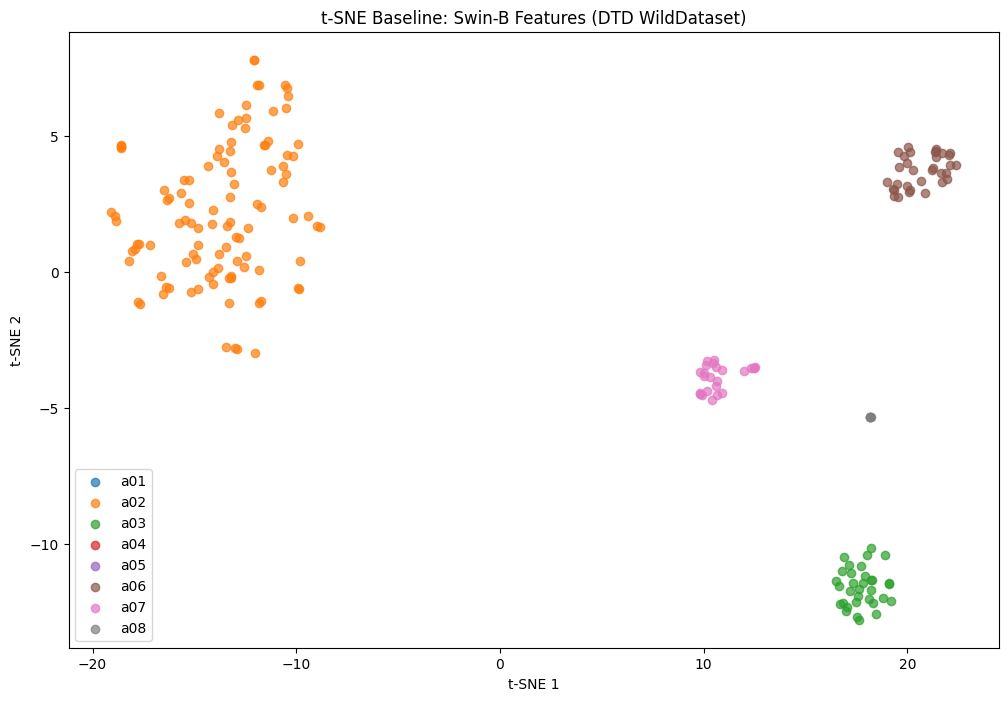

In [36]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

def plot_tsne_baseline(model, dataloader, class_names):
    model.eval()
    all_features = []
    all_labels = []

    print("Extracting features for t-SNE...")
    with torch.no_grad():
        for images, labels in dataloader:
            if isinstance(images, list): images = images[0]
            images = images.to(cudaDevice)
            
            # Get the raw backbone features (1024-dim)
            features = model.backbone(images)
            if len(features.shape) == 3:
                features = features.mean(dim=1) # Global Average Pooling
            
            all_features.append(features.cpu().numpy())
            all_labels.append(labels.numpy())

    # Flatten the lists
    X = np.concatenate(all_features)
    y = np.concatenate(all_labels)

    # Compute t-SNE
    print("Computing t-SNE (this may take a minute)...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_embedded = tsne.fit_transform(X)

    # Plotting
    plt.figure(figsize=(12, 8))
    for i, class_name in enumerate(class_names):
        idxs = np.where(y == i)
        plt.scatter(X_embedded[idxs, 0], X_embedded[idxs, 1], label=class_name, alpha=0.7)

    plt.legend()
    plt.title("t-SNE Baseline: Swin-B Features (DTD WildDataset)")
    #plt.xlabel("t-SNE 1")
    #plt.ylabel("t-SNE 2")
    plt.show()

# Run it on your validation set
plot_tsne_baseline(model, val_loader, plastic_classes)